In [106]:
import numpy as np
from matplotlib import pyplot as plt

from cr_knee_fit.plotting import (
    CARTO_VIVID,
)

In [107]:
alpha = 2
R0 = 1e-1
mean_R_max = 1
sigma_lgR_max = 0.5
A0 = 1.0  # arbitrary normalization
beta = 1.0


def pl(R: np.ndarray) -> np.ndarray:
    return A0 * (R / R0) ** (-alpha)


def pl_scaled(R: np.ndarray, Rmax: float) -> np.ndarray:
    return Rmax**beta * pl(R)


def single_source_heaviside(R: np.ndarray, Rmax: float, lower: bool = False) -> np.ndarray:
    mask = (R < Rmax) if not lower else (R > Rmax)
    return pl_scaled(R, Rmax) * mask


def single_source_exp(R: np.ndarray, Rmax: float) -> np.ndarray:
    return pl_scaled(R, Rmax) * np.exp(-R / Rmax)


def single_source_exp_Delta(R: np.ndarray, Rmax: float, Delta: float) -> np.ndarray:
    return pl_scaled(R, Rmax) * np.exp(-((R / Rmax) ** Delta))

In [108]:
ln10 = np.log(10)


def lognormal_dist_shape(R: np.ndarray, mu: float, sigma: float, beta: float):
    lgR = np.log10(R)
    return 0.5 * special.erfc((lgR - mu - beta * sigma**2 * ln10) / (np.sqrt(2) * sigma))


def lognormal_dist_norm_bias(mu: float, sigma: float, beta: float):
    return np.exp(mu * beta * ln10 + 0.5 * (beta * ln10 * sigma) ** 2)

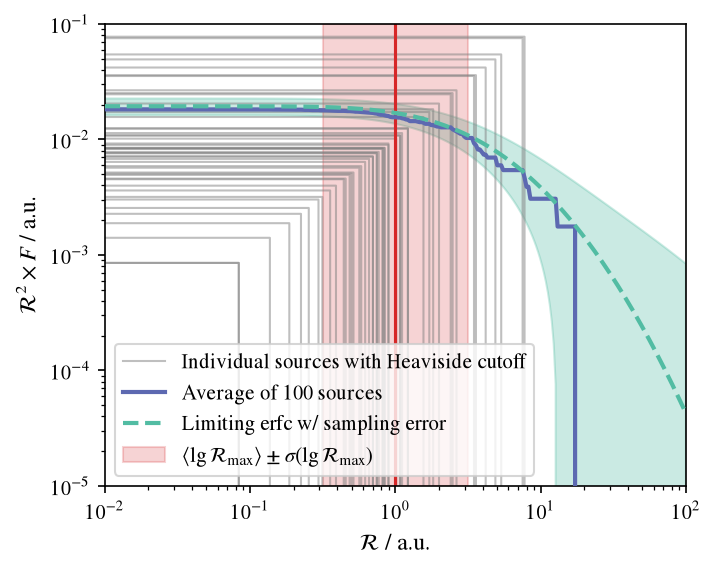

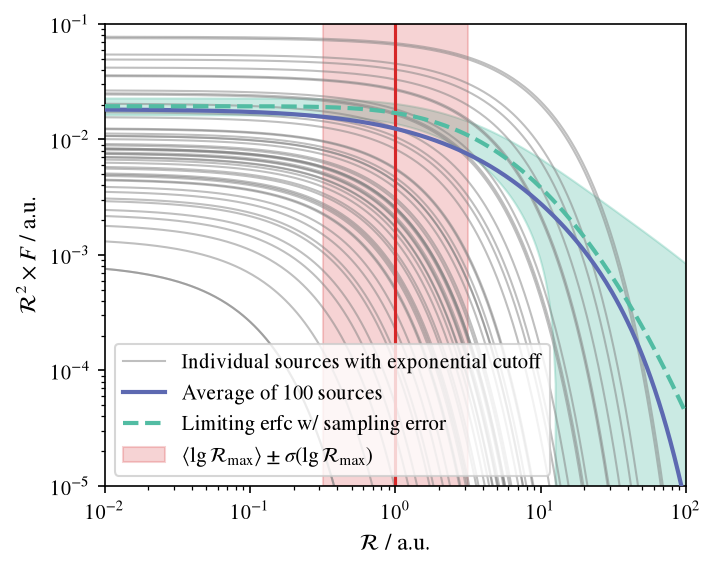

In [109]:
from scipy import special, stats

n_sources = 100
mu = np.log10(mean_R_max)
sigma = sigma_lgR_max
Rmax_sample = 10 ** stats.norm.rvs(mu, sigma, size=n_sources)

for single_source, cutoff_label, added_sigma in (
    (single_source_heaviside, "Heaviside", None),
    (single_source_exp, "exponential", None),
):
    R_grid = np.geomspace(1e-2, 1e2, 300)

    sources = []
    for Rmax in Rmax_sample:
        sources.append(single_source(R_grid, Rmax))

    fig, ax = plt.subplots(figsize=(5, 4))
    scale = 2

    for i, spec in enumerate(sources[:50]):
        ax.plot(
            R_grid,
            R_grid**scale * spec,
            lw=1,
            color="gray",
            alpha=0.5,
            label=f"Individual sources with {cutoff_label} cutoff" if i == 0 else None,
        )

    ax.plot(
        R_grid,
        R_grid**scale * np.mean(sources, axis=0),
        lw=2,
        color=CARTO_VIVID(1),
        zorder=100,
        label=f"Average of {Rmax_sample.size} sources",
    )

    if added_sigma is not None:
        sigma += added_sigma

    mean_theory = (
        lognormal_dist_norm_bias(mu, sigma, beta)
        * pl(R_grid)
        * lognormal_dist_shape(R_grid, mu, sigma, beta)
    )
    mean_sq_theory = (
        A0
        * lognormal_dist_norm_bias(mu, sigma, 2 * beta)
        * pl(R_grid) ** 2
        * lognormal_dist_shape(R_grid, mu, sigma, 2 * beta)
    )
    std_theory = np.sqrt(mean_sq_theory - mean_theory**2)
    std_mean = std_theory / np.sqrt(n_sources)

    theory_label = "Limiting $\\text{erfc}$ w/ sampling error"
    if added_sigma is not None:
        theory_label += f"(added $\\sigma(\\lg \\mathcal{{R}}) = {added_sigma:.2g}$)"

    ax.plot(
        R_grid,
        R_grid**scale * mean_theory,
        lw=2,
        ls="--",
        color=CARTO_VIVID(2),
        label=theory_label,
        zorder=100,
    )
    ax.fill_between(
        R_grid,
        R_grid**scale * (mean_theory - std_mean),
        R_grid**scale * (mean_theory + std_mean),
        color=CARTO_VIVID(2),
        alpha=0.3,
    )

    ax.axvline(10**mu, color="tab:red")
    ax.axvspan(
        10 ** (mu - sigma),
        10 ** (mu + sigma),
        color="tab:red",
        alpha=0.2,
        label="$ \\langle \\lg \\mathcal{R}_\\text{max} \\rangle \\pm \\sigma(\\lg \\mathcal{R}_\\text{max}) $",
    )

    ax.set_xlabel("$ \\mathcal{R} $ / a.u.")
    ax.set_ylabel("$ \\mathcal{R}^2 \\times F $ / a.u.")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend()
    ax.set_xlim(R_grid[0], R_grid[-1])
    ax.set_ylim(1e-5, 1e-1)

# $\sigma(\Delta)$ corresponding to a naive $\exp(-(R/R_\text{cut})^\Delta)$ cutoff


In [110]:
import iminuit

R_grid = np.geomspace(1e-2, 3e1, 300)


def fit_lognormal_to_exp(
    verbose: bool, Delta: float, cutoff_depth: float = 1e-2
) -> tuple[np.ndarray, float, float, float]:
    target_shape = single_source_exp_Delta(R_grid, mean_R_max, Delta)
    idx_max = np.nonzero(target_shape / pl(R_grid) < cutoff_depth)[0][0]
    if verbose:
        print(f"Fitting up to index {idx_max} (R = {R_grid[idx_max]:.2g})")

    to_fit = np.log10(target_shape[:idx_max])

    def nll(params: np.ndarray) -> float:
        mu, sigma = params
        approx = np.log10(pl(R_grid) * lognormal_dist_shape(R_grid, mu, sigma, 1.0))[:idx_max]
        return np.sqrt(((to_fit - approx) ** 2).mean())

    res = iminuit.minimize(
        nll,
        x0=[0, 0.3],
        bounds=[(None, None), (0, None)],
    )
    if verbose:
        print(res)
    mu, sigma = res.x
    return target_shape, mu, sigma, res.fun

Fitting up to index 230 (R = 4.7)
  message: Optimization terminated successfully.
  success: True
      fun: 0.043788557510164354
        x: [-4.379e-01  3.639e-01]
 hess_inv: ┌────┬───────────────┐
           │    │     x0     x1 │
           ├────┼───────────────┤
           │ x0 │  0.838  -0.26 │
           │ x1 │  -0.26 0.0851 │
           └────┴───────────────┘
     nfev: 63
     njev: 0
   minuit: ┌─────────────────────────────────────────────────────────────────────────┐
           │                                Migrad                                   │
           ├──────────────────────────────────┬──────────────────────────────────────┤
           │ FCN = 0.04379                    │              Nfcn = 63               │
           │ EDM = 4.05e-08 (Goal: 0.0001)    │                                      │
           ├──────────────────────────────────┼──────────────────────────────────────┤
           │          Valid Minimum           │   Below EDM threshold (goal x 10)

(1e-05, 0.1)

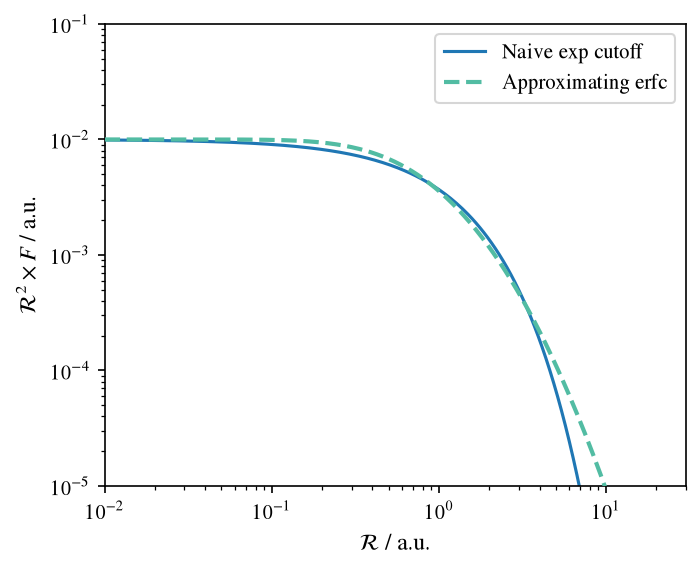

In [111]:
exp_shape, mu, sigma, _ = fit_lognormal_to_exp(verbose=True, Delta=1.0, cutoff_depth=1e-2)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(R_grid, R_grid**2 * exp_shape, label="Naive exp cutoff")

ax.plot(
    R_grid,
    R_grid**scale * pl(R_grid) * lognormal_dist_shape(R_grid, mu, sigma, 1.0),
    lw=2,
    ls="--",
    color=CARTO_VIVID(2),
    zorder=100,
    label="Approximating $\\text{erfc}$",
)

ax.set_xlabel("$ \\mathcal{R} $ / a.u.")
ax.set_ylabel("$ \\mathcal{R}^2 \\times F $ / a.u.")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_xlim(R_grid[0], R_grid[-1])
ax.set_ylim(1e-5, 1e-1)

In [112]:
Delta_grid = np.linspace(0.5, 3, 50)

mus = []
sigmas = []
nlls = []
for Delta in Delta_grid:
    exp_shape, mu, sigma, nll = fit_lognormal_to_exp(verbose=False, Delta=Delta)
    mus.append(mu)
    sigmas.append(sigma)
    nlls.append(nll)

/var/folders/pt/5p7r1p1j49n8f_88l1j7jtwc0000gn/T/ipykernel_36846/2214467201.py:18: RuntimeWarning: divide by zero encountered in log10
  approx = np.log10(pl(R_grid) * lognormal_dist_shape(R_grid, mu, sigma, 1.0))[:idx_max]


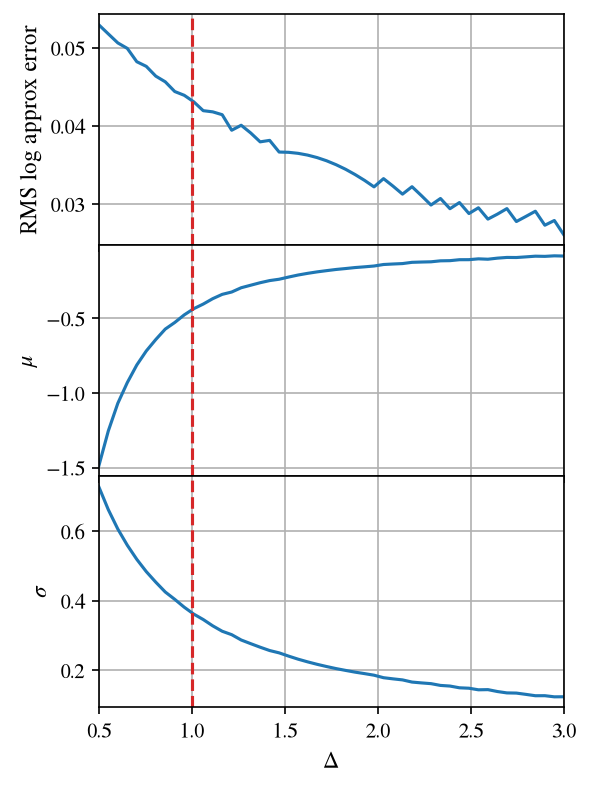

In [113]:
fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(4, 6), sharex=True)

axes[0].plot(Delta_grid, nlls)
axes[0].set_ylabel("RMS log approx error")

axes[1].plot(Delta_grid, mus)
axes[1].set_ylabel("$\\mu$")

axes[2].plot(Delta_grid, sigmas)
axes[2].set_xlabel("$\\Delta$")
axes[2].set_ylabel("$\\sigma$")

axes[2].set_xlim(Delta_grid[0], Delta_grid[-1])


for ax in axes:
    ax.axvline(1.0, color="tab:red", ls="--")
    ax.grid(True, "major")

fig.subplots_adjust(hspace=0)

# Low-R population cutoff

In [130]:
ln10 = np.log(10)


def lower_lognormal_dist_shape(R: np.ndarray, mu: float, sigma: float, beta: float):
    lgR = np.log10(R)
    return 0.5 * (1 + special.erf((lgR - mu - beta * ln10 * sigma**2) / (np.sqrt(2) * sigma)))


def lower_lognormal_dist_norm_bias(mu: float, sigma: float, beta: float):
    return np.exp(mu * beta * ln10 + 0.5 * (beta * ln10 * sigma) ** 2)

(1e-05, 0.1)

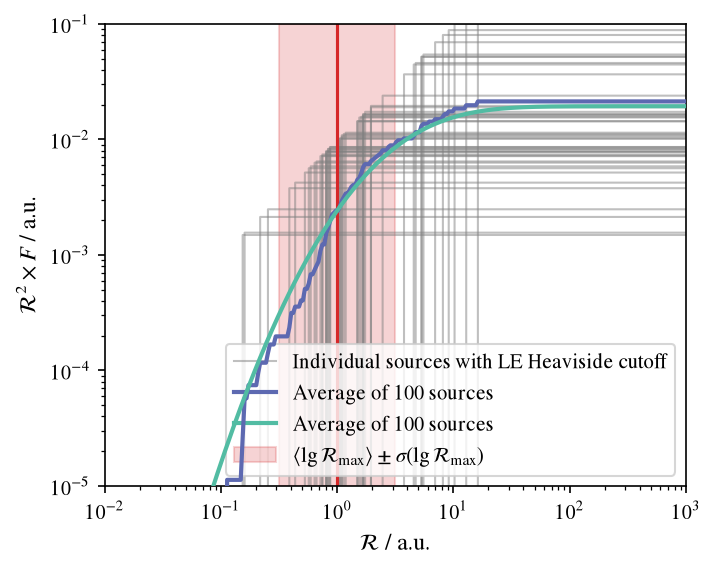

In [132]:
n_sources = 100
mu = np.log10(mean_R_max)
sigma = sigma_lgR_max
Rmax_sample = 10 ** stats.norm.rvs(mu, sigma, size=n_sources)

R_grid = np.geomspace(1e-2, 1e3, 300)

sources = []
for Rmax in Rmax_sample:
    sources.append(single_source_heaviside(R_grid, Rmax, lower=True))

fig, ax = plt.subplots(figsize=(5, 4))
scale = 2

for i, spec in enumerate(sources[:50]):
    ax.plot(
        R_grid,
        R_grid**scale * spec,
        lw=1,
        color="gray",
        alpha=0.5,
        label="Individual sources with LE Heaviside cutoff" if i == 0 else None,
    )

ax.plot(
    R_grid,
    R_grid**scale * np.mean(sources, axis=0),
    lw=2,
    color=CARTO_VIVID(1),
    zorder=100,
    label=f"Average of {Rmax_sample.size} sources",
)

ax.plot(
    R_grid,
    R_grid**scale
    * lower_lognormal_dist_norm_bias(mu, sigma, beta)
    * pl(R_grid)
    * lower_lognormal_dist_shape(R_grid, mu, sigma, beta),
    lw=2,
    color=CARTO_VIVID(2),
    zorder=100,
    label=f"Average of {Rmax_sample.size} sources",
)

ax.axvline(10**mu, color="tab:red")
ax.axvspan(
    10 ** (mu - sigma),
    10 ** (mu + sigma),
    color="tab:red",
    alpha=0.2,
    label="$ \\langle \\lg \\mathcal{R}_\\text{max} \\rangle \\pm \\sigma(\\lg \\mathcal{R}_\\text{max}) $",
)

ax.set_xlabel("$ \\mathcal{R} $ / a.u.")
ax.set_ylabel("$ \\mathcal{R}^2 \\times F $ / a.u.")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_xlim(R_grid[0], R_grid[-1])
ax.set_ylim(1e-5, 1e-1)